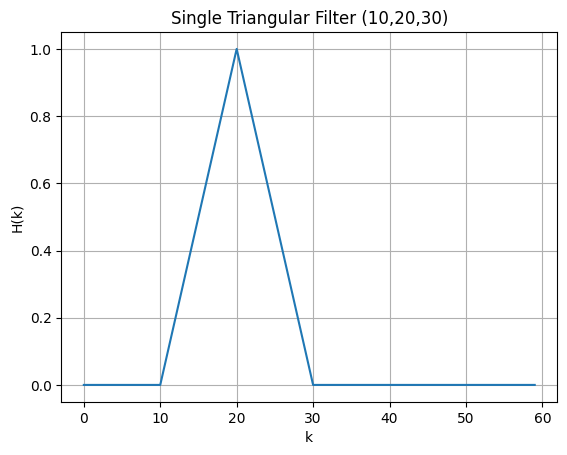

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def triangular_filter(k, a, b, c):
    H = np.zeros_like(k, dtype=float)

    for i in range(len(k)):
        if k[i] < a:
            H[i] = 0
        elif a <= k[i] <= b:
            H[i] = (k[i] - a) / (b - a)
        elif b <= k[i] <= c:
            H[i] = (c - k[i]) / (c - b)
        else:
            H[i] = 0

    return H

# Define k range
k = np.arange(0, 60)

# Single triangle
a, b, c = 10, 20, 30
H = triangular_filter(k, a, b, c)

plt.plot(k, H)
plt.title("Single Triangular Filter (10,20,30)")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.grid()
plt.show()

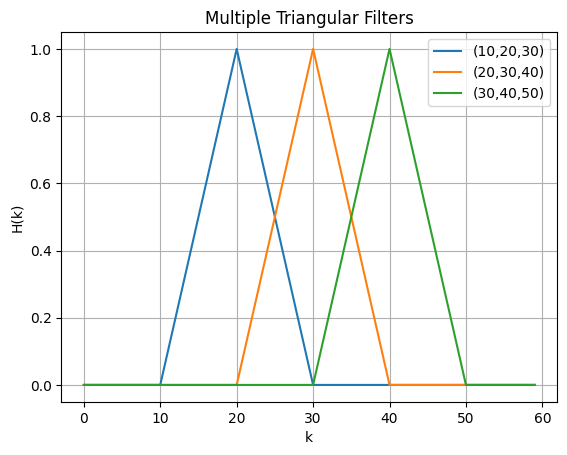

In [ ]:
filters = [(10, 20, 30), (20, 30, 40), (30, 40, 50)]

plt.figure()

for (a, b, c) in filters:
    H = triangular_filter(k, a, b, c)
    plt.plot(k, H, label=f"({a},{b},{c})")

plt.title("Multiple Triangular Filters")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()

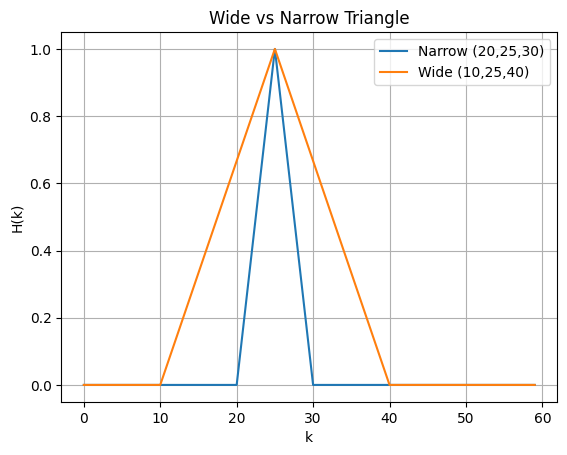

In [ ]:
plt.figure()

# Narrow
H1 = triangular_filter(k, 20, 25, 30)
plt.plot(k, H1, label="Narrow (20,25,30)")

# Wide
H2 = triangular_filter(k, 10, 25, 40)
plt.plot(k, H2, label="Wide (10,25,40)")

plt.title("Wide vs Narrow Triangle")
plt.xlabel("k")
plt.ylabel("H(k)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Parameters
fs = 16000
N = 512
M = 20

fmin = 0
fmax = fs // 2

In [ ]:
def hz_to_mel(f):
    return 2595 * np.log10(1 + f / 700)

def mel_to_hz(m):
    return 700 * (10**(m / 2595) - 1)

In [ ]:
mel_min = hz_to_mel(fmin)
mel_max = hz_to_mel(fmax)

mel_points = np.linspace(mel_min, mel_max, M + 2)

In [ ]:
hz_points = mel_to_hz(mel_points)

In [ ]:
bins = np.floor((N + 1) * hz_points / fs).astype(int)

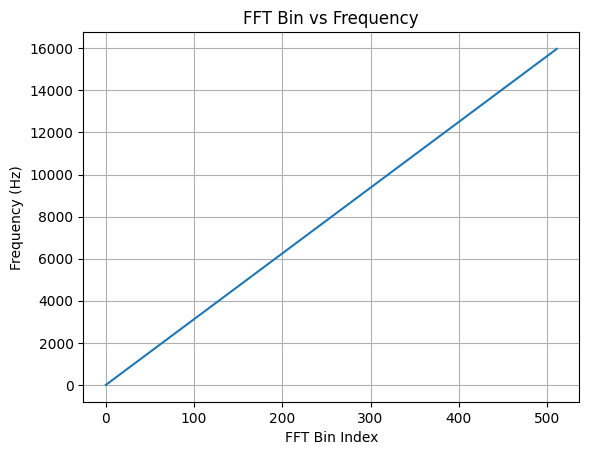

In [ ]:
k = np.arange(0, N)
frequencies = k * fs / N

plt.plot(k, frequencies)
plt.title("FFT Bin vs Frequency")
plt.xlabel("FFT Bin Index")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()

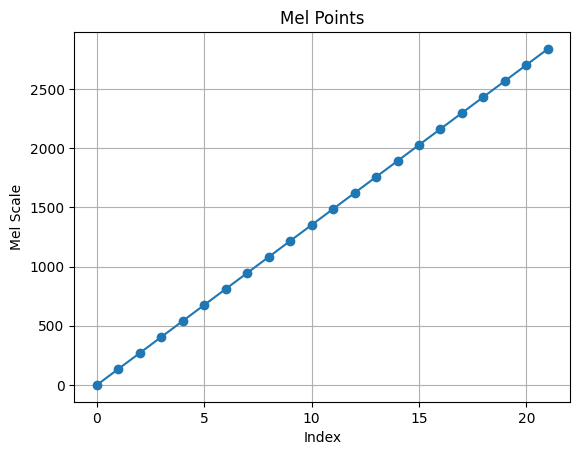

In [ ]:
plt.plot(mel_points, marker='o')
plt.title("Mel Points")
plt.xlabel("Index")
plt.ylabel("Mel Scale")
plt.grid()
plt.show()

In [ ]:
print("Triangular filter points (a, b, c):")
for m in range(1, M + 1):
    a = bins[m - 1]
    b = bins[m]
    c = bins[m + 1]
    print(f"Filter {m}: ({a}, {b}, {c})")

Triangular filter points (a, b, c):
Filter 1: (0, 2, 6)
Filter 2: (2, 6, 9)
Filter 3: (6, 9, 13)
Filter 4: (9, 13, 18)
Filter 5: (13, 18, 23)
Filter 6: (18, 23, 29)
Filter 7: (23, 29, 36)
Filter 8: (29, 36, 43)
Filter 9: (36, 43, 52)
Filter 10: (43, 52, 61)
Filter 11: (52, 61, 72)
Filter 12: (61, 72, 84)
Filter 13: (72, 84, 97)
Filter 14: (84, 97, 113)
Filter 15: (97, 113, 130)
Filter 16: (113, 130, 150)
Filter 17: (130, 150, 172)
Filter 18: (150, 172, 196)
Filter 19: (172, 196, 224)
Filter 20: (196, 224, 256)


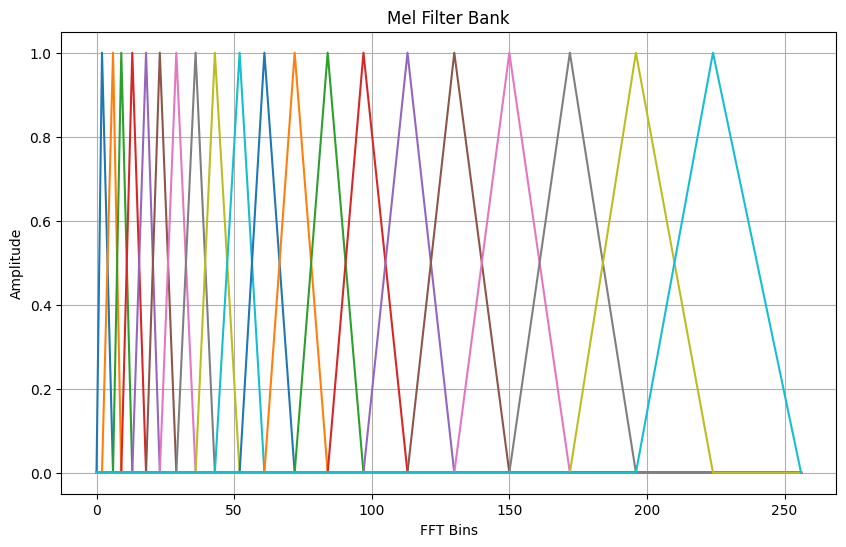

In [ ]:
filter_bank = np.zeros((M, N // 2 + 1))

for m in range(1, M + 1):
    a = bins[m - 1]
    b = bins[m]
    c = bins[m + 1]

    for k in range(a, b):
        filter_bank[m - 1, k] = (k - a) / (b - a)

    for k in range(b, c):
        filter_bank[m - 1, k] = (c - k) / (c - b)

# Plot
plt.figure(figsize=(10,6))

for i in range(M):
    plt.plot(filter_bank[i])

plt.title("Mel Filter Bank")
plt.xlabel("FFT Bins")
plt.ylabel("Amplitude")
plt.grid()
plt.show()